## Build a graph wiht parallelization Fan in and Fan out 

### Build a reassearch agent:
- We want to gather context from two external sources (Wikipedia and Tavily Web-Search) and have an LLM answer a question.

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [3]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-2.5-flash" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

'Today is **Wednesday, May 15, 2024**.'

In [4]:
# Set Tavily for web search
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from tavily import TavilyClient

client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

response = client.search("What is LangGraph?")
print(response)


{'query': 'What is LangGraph?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/', 'title': 'What is LangGraph? - GeeksforGeeks', 'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for building gra

### Build a graph

In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Annotated, List, Literal
from operator import add 
from langchain_core.messages import HumanMessage, AIMessage , SystemMessage 

# import WikipediaLoader and Tavily search module
from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch

# create a class for summary_context from websearch

class State(TypedDict):
    Question: str
    Answer:str
    summery_context: Annotated[list[str],add]



In [8]:
#check how data is printed
def websearch(question):
    ''' retrive documents from the search'''
    tavily_Search = TavilySearch(max_results =3)
    #data = tavily_Search.invoke({'query': state['Question']})
    data = tavily_Search.invoke({'query': question})
    print(data)
    return data

question = "What is love?"
websearch(question)

{'query': 'What is love?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://en.wikipedia.org/wiki/What_Is_Love', 'title': 'What Is Love - Wikipedia', 'content': '"What Is Love" is a song by Trinidadian singer Haddaway, released as his debut single from his debut album, The Album (1993). The song, both written and', 'score': 0.998487, 'raw_content': None}, {'url': 'https://www.verywellmind.com/what-is-love-2795343', 'title': 'What Love Is and How to Cultivate It - Verywell Mind', 'content': 'Love is a complex blend of emotions, thoughts, and behaviors that are shaped by biology and life experiences. People show and experience', 'score': 0.99341017, 'raw_content': None}, {'url': 'https://open.spotify.com/track/6FBPV4s6N8fNnB0TSKU8R1', 'title': 'What Is Love - song and lyrics by Haddaway - Spotify', 'content': "Lyrics. What is love? Oh baby, don't hurt me. Don't hurt me no more. Baby, don't hurt me. Don't hurt me no more. ♪. What is love?", 'score': 

{'query': 'What is love?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/What_Is_Love',
   'title': 'What Is Love - Wikipedia',
   'content': '"What Is Love" is a song by Trinidadian singer Haddaway, released as his debut single from his debut album, The Album (1993). The song, both written and',
   'score': 0.998487,
   'raw_content': None},
  {'url': 'https://www.verywellmind.com/what-is-love-2795343',
   'title': 'What Love Is and How to Cultivate It - Verywell Mind',
   'content': 'Love is a complex blend of emotions, thoughts, and behaviors that are shaped by biology and life experiences. People show and experience',
   'score': 0.99341017,
   'raw_content': None},
  {'url': 'https://open.spotify.com/track/6FBPV4s6N8fNnB0TSKU8R1',
   'title': 'What Is Love - song and lyrics by Haddaway - Spotify',
   'content': "Lyrics. What is love? Oh baby, don't hurt me. Don't hurt me no more. Baby, don't hurt me. Don't hurt me

In [35]:
# Get wiki docs
def search_Wiki(question):
    ''' retrive wiki information'''
    search_docs = WikipediaLoader(query=question, load_max_docs=3, doc_content_chars_max=1000).load()
    return search_docs
    
q = "How were Nvidia's Q2 2025 earnings"
search_docs = search_Wiki(q)

In [39]:
for doc in search_docs:
    formatted_data =""
    for doc in search_docs:
        formatted_data = formatted_data + f'<Document Title: {doc.metadata['title']}\n URL: {doc.metadata['source']}\n content: {doc.metadata['summary']}\n--\nDocument>'
    print(formatted_data)
    print("-"*70)

<Document Title: Nvidia
 URL: https://en.wikipedia.org/wiki/Nvidia
 content: Nvidia Corporation ( en-VID-ee-ə) is an American technology company headquartered in Santa Clara, California. The company develops graphics processing units (GPUs), systems on chips (SoCs), and application programming interfaces (APIs) for data science, high-performance computing, video games, and mobile and automotive applications. Founded in 1993 by Jensen Huang, Chris Malachowsky, and Curtis Priem, Nvidia has been widely described as a Big Tech company.
Originally focused on GPUs for video games, Nvidia broadened their use into other markets, including artificial intelligence (AI), professional visualization, and supercomputing. The company's product lines include GeForce GPUs for gaming and creative workloads, and professional GPUs for edge computing, scientific research, and industrial applications. As of the first quarter of 2025, Nvidia held a 92% share of the discrete desktop and laptop GPU market.
In 

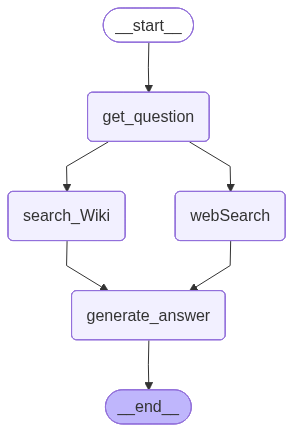

In [42]:
# set the node function
# node for websearch
def webSearch(state:State):
    ''' retrive documents from the search'''
    tavily_Search = TavilySearch(max_results =3)
    response = tavily_Search.invoke({'query': state['Question']})
    results = response.get('results', response)
    formated_result =""
    for result in results:
        formated_result = formated_result + f"<Document Title: {result['title']} \n URL: {result['url']} \n content: {result['content']}\n--\n>Document"

    return {'summery_context': [formated_result] }

# Node for WikiSearch
def search_Wiki(state:State):
    ''' retrive wiki information'''
    search_docs = WikipediaLoader(query=state['Question'], load_max_docs=3, doc_content_chars_max=1000).load()
    formatted_data =""
    for doc in search_docs:
        formatted_data = formatted_data + f'<Document Title: {doc.metadata['title']}\n URL: {doc.metadata['source']}\n content: {doc.metadata['summary']}\n--\nDocument>'
        
    return {'summery_context': [formatted_data] }
    
# Node to get question
def get_question(state:State):
    print("finding the best answer....")
    return state

def generate_answer(state:State):
    '''Node to answer the questions'''
    question = state['Question']
    context = state['summery_context']

    sys_intru = SystemMessage(content=f"You are a Guide who is an expert in Answering the question {question} using the context {context} in a beautiful format")
    
    answer = llm.invoke([sys_intru]+[HumanMessage(content=f"Answer the question.")]) # llm needs human message as a prompt to respond
    return {'Answer' : answer}

# Build a graph
builder = StateGraph(State)

# add nodes and adges
builder.add_node('get_question' , get_question)
builder.add_node('webSearch' , webSearch)
builder.add_node('search_Wiki' , search_Wiki)
builder.add_node('generate_answer' , generate_answer)

# Flow
builder.add_edge(START, 'get_question')
builder.add_edge('get_question', 'webSearch')
builder.add_edge('get_question', 'search_Wiki')
builder.add_edge('search_Wiki', 'generate_answer')
builder.add_edge('webSearch', 'generate_answer')
builder.add_edge('generate_answer', END)

# Compile
graph = builder.compile()

graph
    

In [43]:
# invoke with a question
Question = "Do you support ICE? "

graph.invoke({'Question': Question})

finding the best answer....


{'Question': 'Do you support ICE? ',
 'Answer': AIMessage(content='As an expert Guide, I can provide you with information regarding support for ICE, based on the provided documents. It\'s important to note that "ICE" in this context refers to the U.S. Immigration and Customs Enforcement agency, not the "Miracle on Ice" hockey game or the artist "Ice Cube."\n\nBased on the context, there are varying perspectives on supporting ICE:\n\n### **Arguments and Data Indicating Support for ICE:**\n\n*   **Law Enforcement Perspective:** An opinion poll on Facebook suggests strong support from law enforcement, stating: "It\'s no secret that 99% of us active and retired police officers support ice 100%."\n*   **Enforcement of Immigration Laws:** Some individuals support ICE based on the principle of national sovereignty and law enforcement. One Reddit user articulated this view, stating: "A country that refuses to enforce its own immigration laws is not a serious country. Borders are meaningless if